# 0. Runtime

Disconnect Runtime

In [ ]:
from google.colab import runtime
runtime.unassign()

Examine GPU

In [ ]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sat Feb 28 14:26:31 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             47W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

Examine RAM

In [ ]:
import psutil

ram_gb = psutil.virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 89.6 gigabytes of available RAM

You are using a high-RAM runtime!


# 1. Load Data

Install Python packages

In [2]:
!apt-get -y install fonts-thai-tlwg
!pip install iterative-stratification datasets accelerate pythainlp
!pip install -U transformers tokenizers sentencepiece huggingface_hub

'apt-get' is not recognized as an internal or external command,
operable program or batch file.


   ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
   --- ------------------------------------ 1.0/10.7 MB 9.3 MB/s eta 0:00:02
   ---------- ----------------------------- 2.9/10.7 MB 9.1 MB/s eta 0:00:01
   ------------------------------------ --- 9.7/10.7 MB 18.1 MB/s eta 0:00:01
   ---------------------------------------- 10.7/10.7 MB 18.3 MB/s  0:00:00
   ---------------------------------------- 0.0/596.3 kB ? eta -:--:--
   ---------------------------------------- 596.3/596.3 kB 20.0 MB/s  0:00:00

  Attempting uninstall: huggingface_hub

    Found existing installation: huggingface_hub 1.4.1

    Uninstalling huggingface_hub-1.4.1:

      Successfully uninstalled huggingface_hub-1.4.1

   ---------------------------------------- 0/2 [huggingface_hub]
   ---------------------------------------- 0/2 [huggingface_hub]
   ---------------------------------------- 0/2 [huggingface_hub]
   ---------------------------------------- 0/2 [huggingface_hub]
   -------------

In [ ]:
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [6]:
train_path = "data/raw/train.csv"
real_path = "data/raw/test.csv"

In [ ]:
train_path = "/content/drive/MyDrive/dsde/data/train.csv"
real_path = "/content/drive/MyDrive/dsde/data/test.csv"

In [7]:
import pandas as pd
train_df = pd.read_csv(train_path)
# real_df = pd.read_csv(test_path)

In [9]:
"""
Label Columns:
'สำนักงานตำรวจแห่งชาติ',
'การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย', 
'สภาเด็กและเยาวชนกรุงเทพมหานคร',
'กรมควบคุมมลพิษ', 
'กรมสรรพสามิต', 
'การไฟฟ้านครหลวง', 
'กรมทางหลวง',
'สำนักงานประกันสุขภาพแห่งชาติ', 
'การประปานครหลวง',
'คณะกรรมการการพัฒนาเศรษฐกิจ', 
'กระทรวงการท่องเที่ยวและกีฬา',
'สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200'
"""

label_cols = []

for label in train_df.columns[2:]:
    label_cols.append(label)

In [9]:
label_cols

['สำนักงานตำรวจแห่งชาติ',
 'การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย',
 'สภาเด็กและเยาวชนกรุงเทพมหานคร',
 'กรมควบคุมมลพิษ',
 'กรมสรรพสามิต',
 'การไฟฟ้านครหลวง',
 'กรมทางหลวง',
 'สำนักงานประกันสุขภาพแห่งชาติ',
 'การประปานครหลวง',
 'คณะกรรมการการพัฒนาเศรษฐกิจ',
 'กระทรวงการท่องเที่ยวและกีฬา',
 'สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200']

# 2. EDA

In [52]:
train_df.shape

(306419, 14)

In [ ]:
train_df.head(2)

Download Thai Font

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

# rebuild font cache
fm._load_fontmanager(try_read_cache=False)

mpl.rcParams['font.family'] = 'Tahoma' # Garuda
mpl.rcParams['axes.unicode_minus'] = False

Check Fonts

In [14]:
for f in fm.fontManager.ttflist:
    if 'Thai' in f.name or 'Garuda' in f.name:
        print(f.name)

### Plot Label's Distribution

In [139]:
label_cols = train_df.columns[2:] # id, comment, 12 labels
label_distribution = train_df[label_cols].sum().sort_values(ascending=False)

print(label_distribution)

สำนักงานตำรวจแห่งชาติ                    31953
การไฟฟ้านครหลวง                          18477
กรมทางหลวง                                6891
สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200     4232
การประปานครหลวง                           2799
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย         2490
กรมควบคุมมลพิษ                            1823
สำนักงานประกันสุขภาพแห่งชาติ                69
กรมสรรพสามิต                                45
กระทรวงการท่องเที่ยวและกีฬา                 42
คณะกรรมการการพัฒนาเศรษฐกิจ                  30
สภาเด็กและเยาวชนกรุงเทพมหานคร               29
dtype: int64


In [171]:
# plt.figure(figsize=(14,6))

# bars = plt.barh(
#     label_distribution.index, 
#     label_distribution.values, 
#     color="#8ecae6",
#     )

# for bar in bars:
#     width = bar.get_width()
#     plt.text(
#         width,
#         bar.get_y() + bar.get_height()/2,
#         f'{int(width)}',
#         va='center',
#         fontsize=8,
#     )

# plt.xlabel("Count")
# plt.ylabel("Labels")
# plt.title("Label Distribution (Train Set)")
# plt.grid(axis='x', linestyle='--', alpha=0.7)
# plt.tight_layout()
# plt.show()

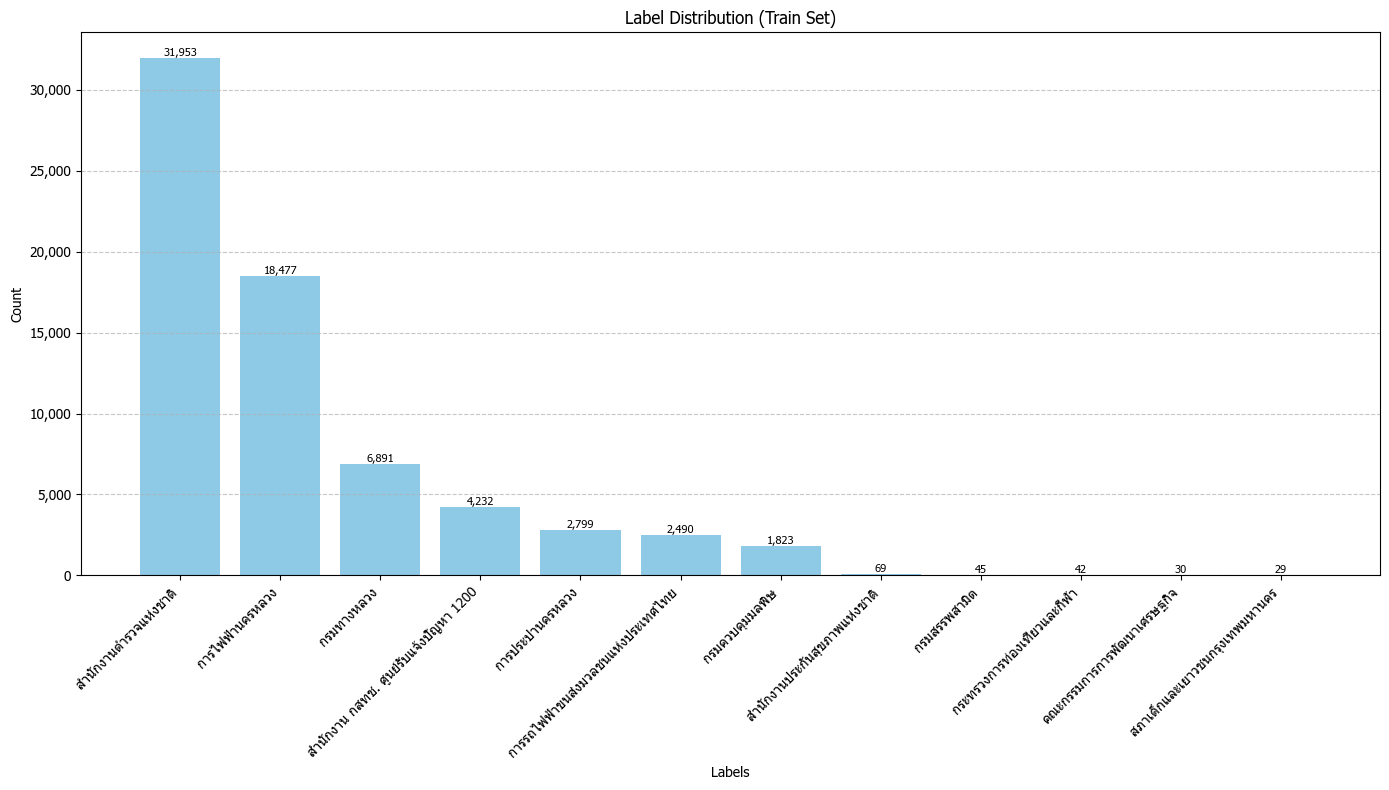

In [ ]:
from matplotlib.ticker import StrMethodFormatter

plt.figure(figsize=(14, 8))

bars = plt.bar(
    label_distribution.index,
    label_distribution.values,
    color="#8ecae6"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.xlabel("Labels")
plt.ylabel("Count")
plt.title("Label Distribution (Train Set)")

plt.xticks(rotation=45, ha="right")

# เส้นประในแกน Y
plt.grid(axis='y', linestyle='--', alpha=0.7)
# ใส่ , ในตัวเลขแกน y
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()

In [10]:
minor_cols = [
    'คณะกรรมการการพัฒนาเศรษฐกิจ', 
    'สภาเด็กและเยาวชนกรุงเทพมหานคร',
    'กระทรวงการท่องเที่ยวและกีฬา', 
    'กรมสรรพสามิต', 
    'สำนักงานประกันสุขภาพแห่งชาติ'
]

In [152]:
train_df.isna().sum()

id                                          0
comment                                  2135
สำนักงานตำรวจแห่งชาติ                       0
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย           0
สภาเด็กและเยาวชนกรุงเทพมหานคร               0
กรมควบคุมมลพิษ                              0
กรมสรรพสามิต                                0
การไฟฟ้านครหลวง                             0
กรมทางหลวง                                  0
สำนักงานประกันสุขภาพแห่งชาติ                0
การประปานครหลวง                             0
คณะกรรมการการพัฒนาเศรษฐกิจ                  0
กระทรวงการท่องเที่ยวและกีฬา                 0
สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200       0
dtype: int64

In [19]:
train_df['comment'].isna().sum()

np.int64(2135)

In [20]:
train_df[train_df['comment'].isna()][label_cols].sum()

สำนักงานตำรวจแห่งชาติ                    120
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย          7
สภาเด็กและเยาวชนกรุงเทพมหานคร              0
กรมควบคุมมลพิษ                             0
กรมสรรพสามิต                               3
การไฟฟ้านครหลวง                           27
กรมทางหลวง                                13
สำนักงานประกันสุขภาพแห่งชาติ               3
การประปานครหลวง                           11
คณะกรรมการการพัฒนาเศรษฐกิจ                 0
กระทรวงการท่องเที่ยวและกีฬา                0
สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200      3
dtype: int64

In [53]:
train_df['comment'].duplicated().sum()

np.int64(31833)

In [ ]:
train_df[train_df['comment'].duplicated()]['comment']

In [11]:
from transformers import AutoTokenizer

model_name = "airesearch/wangchanberta-base-att-spm-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

c:\Users\thara\anaconda3\envs\dsde\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ข้อความยาวผิดปกติ คือ Noise

In [12]:
# TODO: Optimize this
def get_token_length(text):
    return len(tokenizer.encode(str(text), add_special_tokens=True))

In [13]:
train_df["token_len"] = train_df["comment"].apply(get_token_length)

In [24]:
train_df["token_len"].describe()

count    306419.000000
mean         52.747010
std          68.489072
min           3.000000
25%          15.000000
50%          32.000000
75%          69.000000
max        2388.000000
Name: token_len, dtype: float64

In [25]:
train_df["token_len"].quantile([0.9, 0.95, 0.99])

0.90    108.0
0.95    155.0
0.99    338.0
Name: token_len, dtype: float64

In [ ]:
long_samples = train_df[train_df["token_len"] > 512]
len(long_samples[label_cols])
# max_len = 160

835

In [33]:
long_samples[label_cols].sum()

สำนักงานตำรวจแห่งชาติ                    64
การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย         6
สภาเด็กและเยาวชนกรุงเทพมหานคร             0
กรมควบคุมมลพิษ                            2
กรมสรรพสามิต                              0
การไฟฟ้านครหลวง                           7
กรมทางหลวง                                5
สำนักงานประกันสุขภาพแห่งชาติ              1
การประปานครหลวง                           6
คณะกรรมการการพัฒนาเศรษฐกิจ                0
กระทรวงการท่องเที่ยวและกีฬา               0
สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200     0
dtype: int64

# 3. Preprocessing

### Drop Noise

In [14]:
train_df = train_df[train_df["token_len"] <= 512]

In [15]:
train_df = train_df.drop(columns=["token_len"])

In [79]:
train_df.shape

(305584, 14)

### Drop some NA and Duplicated

In [16]:
# แยกส่วนที่เป็น NA ออกมา
df_with_text = train_df[train_df['comment'].notna()]
df_nan = train_df[train_df['comment'].isna()]

In [17]:
# Drop duplicated record
df_with_text = df_with_text.drop_duplicates(subset=['comment']).reset_index(drop=True)

In [18]:
# เลือก NA ออกมาครึ่งหนึ่ง
df_nan_sampled = df_nan.sample(n=int(0.5*len(df_nan)), random_state=42).copy()
df_nan_sampled['comment'] = df_nan_sampled['comment'].fillna("")

In [19]:
# รวมทั้ง 2 ส่วนเข้าด้วยกัน
train_df = pd.concat([df_with_text, df_nan_sampled]).reset_index(drop=True)

In [84]:
train_df.shape

(274857, 14)

### Clean Text

In [20]:
import re

def clean_text(text):
    text = str(text)
    # ลบ URL
    text = re.sub(r'http\S+', '', text)
    # ลบช่องว่างหลายช่องให้เหลือช่องเดียว
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()
    return text

In [21]:
train_df['comment'] = train_df['comment'].apply(clean_text)

### Train Val Test Split

In [22]:
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

X = train_df['comment'].values
y = train_df[label_cols].values

# First split: 80% train, 20% temp
msss1 = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

for train_idx, temp_idx in msss1.split(X, y):
    train_df_split  = train_df.iloc[train_idx]
    temp_df_split = train_df.iloc[temp_idx]

# Prepare temp arrays
X_temp = temp_df_split["comment"].values
y_temp = temp_df_split[label_cols].values

# Second split: split 20% into 10% val and 10% test
msss2 = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.5,
    random_state=42
)

for val_idx, test_idx in msss2.split(X_temp, y_temp):
    val_df_split = temp_df_split.iloc[val_idx]
    test_df_split = temp_df_split.iloc[test_idx]

In [94]:
print(train_df_split.shape)
print(val_df_split.shape)
print(test_df_split.shape)

(219885, 14)
(27486, 14)
(27486, 14)


### Resampling

In [88]:
train_df[minor_cols].sum()

คณะกรรมการการพัฒนาเศรษฐกิจ       30
สภาเด็กและเยาวชนกรุงเทพมหานคร    29
กระทรวงการท่องเที่ยวและกีฬา      42
กรมสรรพสามิต                     45
สำนักงานประกันสุขภาพแห่งชาติ     69
dtype: int64

In [172]:
train_df_split[minor_cols].sum()

คณะกรรมการการพัฒนาเศรษฐกิจ       24
สภาเด็กและเยาวชนกรุงเทพมหานคร    23
กระทรวงการท่องเที่ยวและกีฬา      34
กรมสรรพสามิต                     36
สำนักงานประกันสุขภาพแห่งชาติ     55
dtype: int64

In [168]:
train_df_split[minor_cols].sum().sum() / len(train_df_split) * 100

np.float64(0.07822270732428314)

In [23]:
import random
from pythainlp.tokenize import word_tokenize
import pandas as pd

# TODO: Try WordNet
def simple_swap_augment(text):
    if not isinstance(text, str) or len(text) < 10:
        return text
    try:
        words = word_tokenize(text, engine="newmm")
        if len(words) > 4:
            # Random Swap
            idx1, idx2 = random.sample(range(len(words)), 2)
            words[idx1], words[idx2] = words[idx2], words[idx1]
            return "".join(words)
        return text
    except:
        return text

def multi_label_resampling(df, label_cols, minor_cols, target_min=20, target_max=8000):
    # 1. แยกแถวที่มี Minor Label อย่างน้อย 1 Label ออกมา
    is_minor = df[minor_cols].any(axis=1)
    protected_df = df[is_minor].copy()

    # 2. แยกแถวที่มี Minor Label ผสมเลยออกมา
    major_only_df = df[~is_minor].copy()

    # 3. จัดการกลุ่ม major_only_df (Undersample เฉพาะกลุ่มนี้)
    final_major_indices = set()
    major_labels = [c for c in label_cols if c not in minor_cols]

    # Undersampling แต่ละ label ของ major_labels ให้เหลือ min(ของเดิม, target_max)
    for label in major_labels:
        col_df = major_only_df[major_only_df[label] == 1]
        if len(col_df) > target_max:
            # สุ่มลดเฉพาะแถวที่มีแต่ major_labels
            sampled_idx = col_df.sample(n=target_max, random_state=42).index
            final_major_indices.update(sampled_idx)
        else:
            final_major_indices.update(col_df.index)

    sampled_major_df = major_only_df.loc[list(final_major_indices)]

    # 4. รวม major และ minor labels แล้ว drop record ที่ซ้ำกัน
    combined_df = pd.concat([sampled_major_df, protected_df]).drop_duplicates()

    # 5. ทำ Oversampling (Augment) ให้ Minor Label ขึ้นมาถึงเป้า เพื่อไม่ให้ Minor Label น้อยเกินไปจน Model เรียนรู้ไม่ได้
    oversampled_list = [combined_df]
    for label in minor_cols:
        rows = combined_df[combined_df[label] == 1]
        if 0 < len(rows) < target_min:
            num_to_add = target_min - len(rows)
            upsampled = rows.sample(n=int(num_to_add), replace=True, random_state=42).copy()
            upsampled['comment'] = upsampled['comment'].apply(simple_swap_augment)
            oversampled_list.append(upsampled)

    # 6. รวม Oversampling
    combined_labeled_df = pd.concat(oversampled_list)

    # 7. ดึงข้อมูล "ศูนย์ล้วน" (Negative Samples) มาเติม (df ควรเป็น df_train ที่แยก Val ออกไปแล้ว)
    df_empty = df[df[label_cols].sum(axis=1) == 0]

    # สุ่มมาตามเป้า (0.3 - 0.5 ของจำนวน record ที่มี label หรือ heuristic อื่นที่เหมาะสม)
    n_empty = min(len(df_empty), int(0.3*len(combined_labeled_df)))
    sampled_empty = df_empty.sample(n=n_empty, random_state=42)

    # 8. รวม Positive Label กับ Negative Label
    final_df = pd.concat([combined_labeled_df, sampled_empty])

    # 9. Shuffle เพื่อไม่ให้โมเดลจำลำดับ
    return final_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [24]:
train_df_resampling = multi_label_resampling(train_df_split, label_cols, minor_cols)

In [96]:
print(train_df_split.shape)
print(train_df_resampling.shape)

(219885, 14)
(38747, 14)


In [ ]:
# import torch
# from torch.utils.data import Dataset

# class MultiLabelDataset(Dataset):
#     def __init__(self, df, tokenizer, max_len=160):
#         self.df = df
#         self.tokenizer = tokenizer
#         self.max_len = max_len
#         self.label_cols = df.columns[2:]

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, idx):
#         text = self.df.iloc[idx]['comment']
#         labels = self.df.iloc[idx][self.label_cols].values.astype(float)

#         encoding = self.tokenizer(
#             text,
#             padding='max_length', # TODO True
#             truncation=True,
#             max_length=self.max_len,
#             return_tensors='pt'
#         )

#         return {
#             'input_ids': encoding['input_ids'].flatten(),
#             'attention_mask': encoding['attention_mask'].flatten(),
#             'labels': torch.tensor(labels, dtype=torch.float)
#         }

In [ ]:
# max_len = 160
# train_dataset = MultiLabelDataset(train_df_resampling, tokenizer, max_len)
# val_dataset = MultiLabelDataset(val_df_split, tokenizer, max_len)
# test_dataset = MultiLabelDataset(test_df_split, tokenizer, max_len)

In [27]:
import torch
from torch.utils.data import Dataset
# 1. Encode Texts ก่อนนำเข้า Dataset เพื่อลด Bottleneck
def prepare_data(df, tokenizer, max_len=160):
    texts = df['comment'].tolist()
    labels = df.iloc[:, 2:].values.astype(float)
    encodings = tokenizer(
                    texts, 
                    padding='max_length', 
                    truncation=True,
                    max_length=max_len, 
                    return_tensors=None
                )
    return encodings, labels

# 2. Dataset Class แบบใหม่
class FastMultiLabelDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

In [28]:
train_encs, train_labs = prepare_data(train_df_resampling, tokenizer)
val_encs, val_labs = prepare_data(val_df_split, tokenizer)
test_encs, test_labs = prepare_data(test_df_split, tokenizer)

train_dataset = FastMultiLabelDataset(train_encs, train_labs)
val_dataset = FastMultiLabelDataset(val_encs, val_labs)
test_dataset = FastMultiLabelDataset(test_encs, test_labs)

In [30]:
torch.save(train_dataset, "data/preprocessed/train_dataset.pt")
torch.save(val_dataset, "data/preprocessed/val_dataset.pt")
torch.save(test_dataset, "data/preprocessed/test_dataset.pt")

In [ ]:
train_dataset = torch.load("data/preprocessed/train_dataset.pt")
val_dataset = torch.load("data/preprocessed/val_dataset.pt")
test_dataset = torch.load("data/preprocessed/test_dataset.pt")

# 4. Training

In [100]:
num_labels = len(label_cols)
id2label = {i: label for i, label in enumerate(label_cols)}
label2id = {label: i for i, label in enumerate(label_cols)}

In [101]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    problem_type="multi_label_classification"
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 885.12it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
CamembertForSequenceClassification LOAD REPORT from: airesearch/wangchanberta-base-att-spm-uncased
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missi

In [102]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import f1_score
import numpy as np

In [103]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    # ใช้ Threshold คงที่ที่ 0.5 ตอน train
    preds = (probs > 0.5).astype(int)

    f1_macro = f1_score(labels, preds, average='macro')
    return {"f1_macro": f1_macro}

In [ ]:
# label_counts = train_df_resampling[label_cols].sum().values
# total_samples = len(train_df_resampling)

# pos_weights = (total_samples - label_counts) / label_counts
# pos_weights = torch.tensor(pos_weights, dtype=torch.float)
# # ใช้ sqrt ช่วยลดความแรง
# pos_weights = torch.sqrt(pos_weights)
# pos_weights = torch.clamp(pos_weights, max=8)

# print(pos_weights)

In [ ]:
# from transformers import Trainer
# import torch.nn as nn

# class WeightedTrainer(Trainer):
#     def __init__(self, pos_weights, *args, **kwargs):
#         super().__init__(*args, **kwargs)
#         self.loss_fct = nn.BCEWithLogitsLoss(
#             pos_weight=pos_weights.to(self.args.device)
#         )

#     def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
#         labels = inputs.pop("labels")
#         outputs = model(**inputs)
#         logits = outputs.logits

#         loss = self.loss_fct(logits, labels)

#         return (loss, outputs) if return_outputs else loss

In [ ]:
# import torch.nn.functional as F

class ASLTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        gamma_pos = 0.0     # gamma_pos เพิ่ม, Precision เพิ่ม
        gamma_neg = 2.0     # gamma_neg เพิ่ม, False Positive ลด, Model ไม่กล้าทำนายหว่าน 0
        clip = 0.00

        # Probabilities
        xs_pos = torch.sigmoid(logits)
        xs_neg = 1.0 - xs_pos

        # ASL Clamping for Stability
        if clip > 0:
            xs_neg = (xs_neg + clip).clamp(max=1)

        # Asymmetric Focusing
        # ฝั่ง Positive (Label=1)
        loss_pos = labels * torch.log(xs_pos.clamp(min=1e-8)) * (1 - xs_pos)**gamma_pos
        # ฝั่ง Negative (Label=0)
        loss_neg = (1 - labels) * torch.log(xs_neg.clamp(min=1e-8)) * (1 - xs_neg)**gamma_neg
        loss = - (loss_pos + loss_neg).mean() # ใช้ .mean() แทนการหาร batch size เฉยๆ

        return (loss, outputs) if return_outputs else loss

In [ ]:
# training_args = TrainingArguments(
#     output_dir='./results',
#     eval_strategy="epoch",
#     save_strategy="epoch",
#     learning_rate=2e-5,
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,
#     num_train_epochs=1,
#     weight_decay=0.01,
#     load_best_model_at_end=True,
# )
#
# trainer = WeightedTrainer(
#     pos_weights=pos_weights,
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     processing_class=tokenizer,
#     compute_metrics=compute_metrics
# )

training_args = TrainingArguments(
    output_dir='./results',
    fp16=True, # เปิดโหมดเร่งสปีด GPU
    dataloader_num_workers=4, # ใช้ CPU ช่วยส่งข้อมูล 4 ตัวขนานกัน
    num_train_epochs=8, # 5 ถึง 10
    per_device_train_batch_size=64, # A100 Runtime
    per_device_eval_batch_size=64,
    learning_rate=2e-5, # LR มาตรฐานสำหรับ BERT
    weight_decay=0.01,
    eval_strategy="epoch", # ประเมินผลทุกครั้งเมื่อจบ 1 Epoch
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none", # ปิดการส่ง log ไป wandb
    # warmup_steps=warmup_steps,
    # label_smoothing_factor=0.1,
)

trainer = ASLTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [ ]:
result_train = trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro
1,0.014078,0.055681,0.441567
2,0.012794,0.062116,0.411027
3,0.013658,0.064533,0.408467
4,0.012304,0.059901,0.404277
5,0.010862,0.069792,0.366829
6,0.010212,0.075253,0.383179
7,0.008923,0.072402,0.407492
8,0.007836,0.073485,0.395303


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

In [ ]:
from datetime import datetime
now = datetime.now()
dt_string = now.strftime("%Y%m%d_%H%M%S")

In [ ]:
trainer.save_model(f'/content/drive/MyDrive/dsde/model_final_finetune_{dt_string}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# metrics = trainer.evaluate()
# print(metrics)

In [ ]:
# หากต้องการ train ต่อ
# trainer.train(resume_from_checkpoint=last_checkpoint)

# 5. Inference

In [ ]:
val_preds = trainer.predict(val_dataset)
logits = val_preds.predictions
labels = val_preds.label_ids

In [ ]:
probs = torch.sigmoid(torch.tensor(logits)).numpy()

### Thresholds Tuning

In [ ]:
best_thresholds = []

for i in range(num_labels):
    best_f1 = 0
    best_t = 0.5
    for t in np.arange(0.2, 0.9, 0.01):
        preds = (probs[:, i] > t).astype(int)
        f1 = f1_score(labels[:, i], preds)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    best_thresholds.append(best_t)

print(best_thresholds)

[np.float64(0.8600000000000005), np.float64(0.8800000000000006), 0.5, np.float64(0.8500000000000005), np.float64(0.8100000000000005), np.float64(0.7900000000000005), np.float64(0.8900000000000006), np.float64(0.6500000000000004), np.float64(0.8700000000000006), np.float64(0.8100000000000005), np.float64(0.5400000000000003), np.float64(0.8900000000000006)]


### Evaluation

In [ ]:
pred_output = trainer.predict(test_dataset)

logits = pred_output.predictions
labels = pred_output.label_ids

probs = torch.sigmoid(torch.tensor(logits)).numpy()

In [ ]:
final_preds = np.zeros_like(probs)

for i, t in enumerate(best_thresholds):
    final_preds[:, i] = (probs[:, i] > t).astype(int)

In [ ]:
from sklearn.metrics import classification_report
print(
    classification_report(
        labels,
        final_preds,
        target_names=label_cols,
        digits=4,
        zero_division=0
    )
)

                                       precision    recall  f1-score   support

                สำนักงานตำรวจแห่งชาติ     0.7101    0.8101    0.7569      3508
    การรถไฟฟ้าขนส่งมวลชนแห่งประเทศไทย     0.4842    0.5287    0.5055       261
        สภาเด็กและเยาวชนกรุงเทพมหานคร     0.0000    0.0000    0.0000         4
                       กรมควบคุมมลพิษ     0.1970    0.4670    0.2771       197
                         กรมสรรพสามิต     0.6667    0.5000    0.5714         4
                      การไฟฟ้านครหลวง     0.6153    0.7510    0.6764      2004
                           กรมทางหลวง     0.3396    0.6580    0.4480       769
         สำนักงานประกันสุขภาพแห่งชาติ     0.1667    0.4286    0.2400         7
                      การประปานครหลวง     0.4918    0.5974    0.5395       303
           คณะกรรมการการพัฒนาเศรษฐกิจ     1.0000    0.3333    0.5000         3
          กระทรวงการท่องเที่ยวและกีฬา     0.2500    0.2500    0.2500         4
สำนักงาน กสทช. ศูนย์รับแจ้งปัญหา 1200     0.6161   

# 6. Real Dataset

In [31]:
real_df = pd.read_csv(real_path)

In [32]:
real_df['comment'] = real_df['comment'].fillna('')
real_df['comment'] = real_df['comment'].apply(clean_text)

In [ ]:
# class RealDataset(Dataset):
#     def __init__(self, df, tokenizer, max_len=160):
#         self.df = df
#         self.tokenizer = tokenizer
#         self.max_len = max_len

#     def __len__(self):
#         return len(self.df)

#     def __getitem__(self, idx):
#         text = self.df.iloc[idx]['comment']

#         encoding = self.tokenizer(
#             text,
#             padding='max_length',
#             truncation=True,
#             max_length=self.max_len,
#             return_tensors='pt'
#         )

#         return {
#             'input_ids': encoding['input_ids'].flatten(),
#             'attention_mask': encoding['attention_mask'].flatten(),
#         }

In [33]:
# 1. ฟังก์ชันเตรียม Data สำหรับ Real (ไม่มี labels)
def prepare_real_data(df, tokenizer, max_len=160):
    # Recheck ชื่อคอลัมน์
    texts = df['comment'].fillna("").astype(str).tolist()

    encodings = tokenizer(texts,
                          padding='max_length',
                          truncation=True,
                          max_length=max_len,
                          return_tensors=None)
    return encodings

# 2. Dataset Class สำหรับ Test (ไม่ต้องรับ labels)
class FastRealDataset(torch.utils.data.Dataset):
    def __init__(self, encodings):
        self.encodings = encodings

    def __len__(self):
        return len(next(iter(self.encodings.values())))

    def __getitem__(self, idx):
        # ดึง input_ids และ attention_mask ออกมาเป็น tensor
        return {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

In [34]:
test_encodings = prepare_real_data(real_df, tokenizer) # ใช้ max_len เท่าตอนเทรน
real_dataset = FastRealDataset(test_encodings)

In [35]:
torch.save(real_dataset, "data/preprocessed/real_dataset.pt")

In [ ]:
real_dataset = torch.load("real_dataset.pt")

In [ ]:
print(len(real_dataset))
print(len(real_df))

37406
37406


In [ ]:
preds = trainer.predict(real_dataset)

logits = preds.predictions
probs = torch.sigmoid(torch.tensor(logits)).numpy()

final_preds = np.zeros_like(probs)

for i, t in enumerate(best_thresholds):
    final_preds[:, i] = (probs[:, i] > t).astype(int)

In [ ]:
submission = pd.DataFrame(final_preds, columns=label_cols)
submission.insert(0, 'id', real_df['id'])

submission.to_csv(f'/content/drive/MyDrive/dsde/submission_final_finetune_{dt_string}.csv', index=False)